# LightGBM Credit Prediction (lgb.cv + Optuna)

This notebook keeps the **lgb.cv** workflow while adding features from `lgb_pred_codex`:
- 5-fold stratified CV
- Bayesian optimization (Optuna)
- Train/valid AUC gap penalty to reduce overfitting
- Final Train/Test AUC + KS evaluation
- GPU training parameters (optional, enabled by default)


In [5]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import optuna
from optuna.samplers import TPESampler


In [6]:
# --- Data loading ---
DATA_PATH = rf"data\数据及异常值处理方法(1).xlsx"
SHEET_NAME = '原数据'
TARGET_COL = "bad"

raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

cat_cols = [c for c in raw.columns if raw[c].dtype == "object"]
for c in cat_cols:
    raw[c] = raw[c].astype("category")

feature_cols = [c for c in raw.columns if c != TARGET_COL]

X = raw[feature_cols]
y = raw[TARGET_COL].astype(int)

# 4:6 split (test_size=0.4) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (6000, 40)
Test shape: (4000, 40)


In [7]:
def ks_stat(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return float(np.max(tpr - fpr))


def eval_auc_ks(y_true, y_proba, name=""):
    auc_score = roc_auc_score(y_true, y_proba)
    ks = ks_stat(y_true, y_proba)
    if name:
        print(f"{name} AUC: {auc_score:.4f} | KS: {ks:.4f}")
    return auc_score, ks


In [25]:
def make_params(trial=None):
    # Class imbalance
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    scale_pos_weight = float(neg / max(pos, 1))

    base = {
        "device": "gpu",
        "gpu_platform_id": 1,
        "gpu_device_id": 0,
        "gpu_use_dp": False,
        "max_bin": 63,
        "verbosity": -1,
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "seed": 42,
        "scale_pos_weight": scale_pos_weight,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
    }

    if trial is None:
        # Conservative defaults to reduce overfitting
        base.update({
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "min_data_in_leaf": 50,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
        })
        return base

    base.update({
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 3, 31),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 300),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.2),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    })
    return base


In [31]:
def cv_auc_with_gap_penalty(params, nfold=5, num_boost_round=2000):
    train_ds = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols, free_raw_data=False)

    cv_results = lgb.cv(
        params,
        train_ds,
        num_boost_round=num_boost_round,
        nfold=nfold,
        stratified=True,
        shuffle=True,
        metrics="auc",
        seed=42,
        eval_train_metric=True,
        callbacks=[lgb.early_stopping(20)],
    )

    # Support different LightGBM key names across versions
    # Common keys: "auc-mean" (valid), "valid-auc-mean", "train-auc-mean"
    def _pick_mean(keys):
        for k in keys:
            if k in cv_results:
                return k
        return None

    valid_key = _pick_mean(["auc-mean", "valid auc-mean"])
    train_key = _pick_mean(["train auc-mean", "auc-mean"])

    if valid_key is None:
        raise KeyError(f"AUC mean key not found in cv_results. Keys: {list(cv_results.keys())}")

    best_iter = len(cv_results[valid_key])
    mean_auc = float(cv_results[valid_key][-1])

    if train_key is not None:
        mean_train_auc = float(cv_results[train_key][-1])
    else:
        mean_train_auc = mean_auc

    mean_gap = mean_train_auc - mean_auc

    #penalty = max(0.0, mean_gap - 0.05)
    score = mean_auc - 1.2*mean_gap

    return score, mean_auc, mean_gap, best_iter


In [32]:
def objective(trial):
    params = make_params(trial)
    score, mean_auc, mean_gap, best_iter = cv_auc_with_gap_penalty(params)
    trial.set_user_attr("mean_auc", mean_auc)
    trial.set_user_attr("mean_gap", mean_gap)
    trial.set_user_attr("best_iter", best_iter)
    return score


In [35]:
# --- Bayesian optimization (Optuna) ---
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=200,show_progress_bar=True)

best_trial = study.best_trial
best_params = make_params()
best_params.update(best_trial.params)

best_mean_auc = best_trial.user_attrs["mean_auc"]
best_mean_gap = best_trial.user_attrs["mean_gap"]
best_iter = best_trial.user_attrs["best_iter"]

print("Best CV AUC:", round(best_mean_auc, 4))
print("Best CV gap:", round(best_mean_gap, 4))
print("Best iteration:", best_iter)
print("Best params:", best_trial.params)


  0%|          | 0/200 [00:00<?, ?it/s]

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[97]	cv_agg's train auc: 0.942796 + 0.00229553	cv_agg's valid auc: 0.749363 + 0.0282813
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[74]	cv_agg's train auc: 0.954293 + 0.00430875	cv_agg's valid auc: 0.753071 + 0.0299399
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[71]	cv_agg's train auc: 0.928885 + 0.00514651	cv_agg's valid auc: 0.750661 + 0.0135103
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[103]	cv_agg's train auc: 0.896007 + 0.00221134	cv_agg's valid auc: 0.761383 + 0.0172157
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[180]	cv_agg's train auc: 0.871072 + 0.0041561	cv_agg's valid auc: 0.756291 + 0.0291435
Training until validation scores don't improve for 20 rounds
Early stopping, be

In [36]:
# --- Train final model on full train set ---
train_ds = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)

final_model = lgb.train(
    best_params,
    train_ds,
    num_boost_round=best_iter,
    valid_sets=[train_ds],
    valid_names=["train"],
    callbacks=[lgb.log_evaluation(100)],
)

pred_train = final_model.predict(X_train, num_iteration=best_iter)
pred_test = final_model.predict(X_test, num_iteration=best_iter)

train_auc, train_ks = eval_auc_ks(y_train, pred_train, "Train")
test_auc, test_ks = eval_auc_ks(y_test, pred_test, "Test")

print("AUC gap (train - test):", round(train_auc - test_auc, 4))


Train AUC: 0.8300 | KS: 0.5268
Test AUC: 0.7164 | KS: 0.3343
AUC gap (train - test): 0.1136


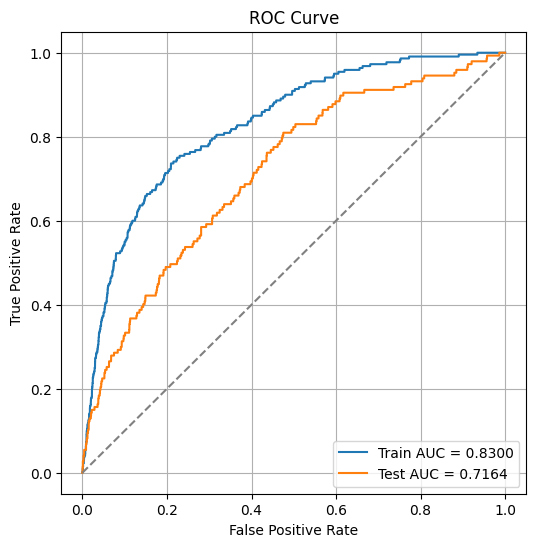

In [37]:
# --- ROC curves ---
import matplotlib.pyplot as plt

fpr_tr, tpr_tr, _ = roc_curve(y_train, pred_train)
fpr_te, tpr_te, _ = roc_curve(y_test, pred_test)

plt.figure(figsize=(6, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train AUC = {train_auc:.4f}")
plt.plot(fpr_te, tpr_te, label=f"Test AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
